
# Swiggy Business Intelligence + Machine Learning Project (Student Scaffold)

## Project Goal
You are working as a **Data Analyst at a food delivery company like Swiggy**.

Your job is to:
1. Explore the dataset
2. Generate business insights
3. Visualize important patterns
4. Build a machine learning model to predict **Order Value**
5. Interpret results like a business analyst

Dataset: `swiggy_orders_dataset.csv`



## Business Questions to Answer

1. Which city generates the highest revenue?
2. Which cuisine is the most popular?
3. Which restaurants generate the highest revenue?
4. Which city has the highest delivery time?
5. Do discounts increase order value?
6. Do highly rated orders have higher value?
7. Which cuisine has the highest average order value?
8. Does delivery time affect customer ratings?
9. Can we predict order value using machine learning?
10. What recommendations can we give to Swiggy?


## Step 1 — Import Required Libraries

In [ ]:

# TODO:
# Import the following libraries:
# pandas
# numpy
# matplotlib.pyplot
# seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 — Load the Dataset

In [ ]:

# TODO:
# Load the dataset using pandas
# File name: swiggy_orders_dataset.csv

# Store it in a variable called 'data'

# Display first 5 rows


In [2]:
a=pd.read_csv("/content/swiggy_orders_dataset_final.csv")

## Step 3 — Understand the Dataset

In [ ]:

# TODO:
# Display dataset information
# Hint: use .info()


In [3]:
a.head()

,Order_ID,City,Restaurant,Cuisine,Delivery_Time,Customer_Rating,Discount,Order_Value
0,1001,Chennai,Spice Kitchen,Italian,48,4.10,10,654
1,1002,Mumbai,Biryani Palace,Indian,25,4.97,0,471
2,1003,Hyderabad,Street Eats,Chinese,55,4.73,15,621
3,1004,Mumbai,Dosa Corner,Fast Food,17,4.28,0,395
4,1005,Mumbai,Taste of India,Italian,42,3.68,15,534


In [4]:
a.tail()

,Order_ID,City,Restaurant,Cuisine,Delivery_Time,Customer_Rating,Discount,Order_Value
595,1596,Bangalore,Street Eats,Indian,30,5.00,15,745
596,1597,Pune,Pizza Hub,Indian,56,4.97,0,382
597,1598,Mumbai,Chaat Junction,Fast Food,50,4.48,0,509
598,1599,Hyderabad,Tandoori Treats,Desserts,44,3.69,0,564
599,1600,Hyderabad,Food Factory,South Indian,32,4.53,5,507


In [5]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         600 non-null    int64  
 1   City             600 non-null    object 
 2   Restaurant       600 non-null    object 
 3   Cuisine          600 non-null    object 
 4   Delivery_Time    600 non-null    int64  
 5   Customer_Rating  600 non-null    float64
 6   Discount         600 non-null    int64  
 7   Order_Value      600 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 37.6+ KB


In [ ]:

# TODO:
# Generate statistical summary of the dataset
# Hint: use .describe()


In [6]:
a.describe()

,Order_ID,Delivery_Time,Customer_Rating,Discount,Order_Value
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,1300.500000,36.980000,4.231917,10.175000,542.988333
std,173.349358,12.853467,0.427847,7.101297,133.792684
min,1001.000000,15.000000,3.500000,0.000000,234.000000
25%,1150.750000,26.000000,3.850000,5.000000,437.000000
50%,1300.500000,37.000000,4.230000,10.000000,539.000000
75%,1450.250000,48.000000,4.610000,15.000000,656.000000
max,1600.000000,59.000000,5.000000,20.000000,866.000000


## Step 4 — Revenue Analysis by City

In [ ]:

# TODO:
# Calculate total revenue by city
# Hint:
# groupby()
# sum()


In [12]:
revenue_city=a.groupby("City")["Order_Value"].sum().sort_values(ascending=False)

In [13]:
revenue_city

,Order_Value
City,
Chennai,62994
Bangalore,57188
Hyderabad,51781
Mysore,51715
Pune,51593
Mumbai,50522


### Visualization: Revenue by City

In [ ]:

# TODO:
# Create a bar chart showing revenue by city


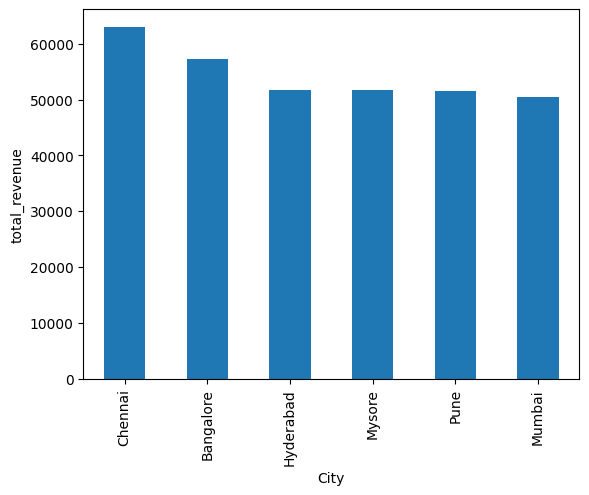

In [15]:
revenue_city.plot(kind='bar')
plt.xlabel("City")
plt.ylabel("total_revenue")
plt.show()

## Step 5 — Most Popular Cuisine

In [ ]:

# TODO:
# Find how many orders exist for each cuisine
# Hint: value_counts()


In [39]:
cuisine_count=a["Cuisine"].value_counts()

In [40]:
cuisine_count

,count
Cuisine,
Indian,108
Italian,105
South Indian,105
Chinese,100
Desserts,100
Fast Food,82


<Axes: xlabel='Cuisine'>

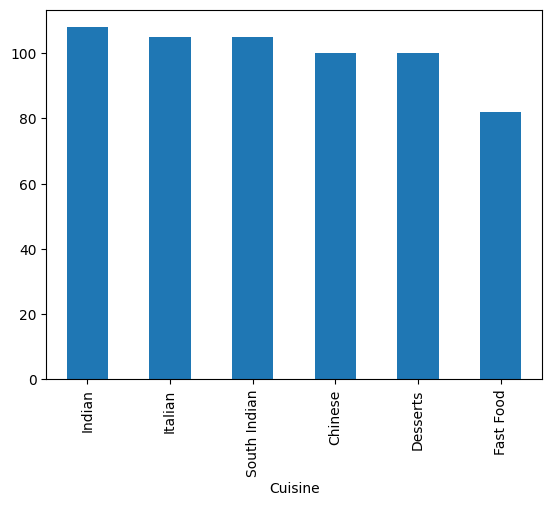

In [42]:
cuisine_count.plot(kind="bar")

In [ ]:

# TODO:
# Create a countplot showing cuisine popularity


<Axes: xlabel='Cuisine', ylabel='count'>

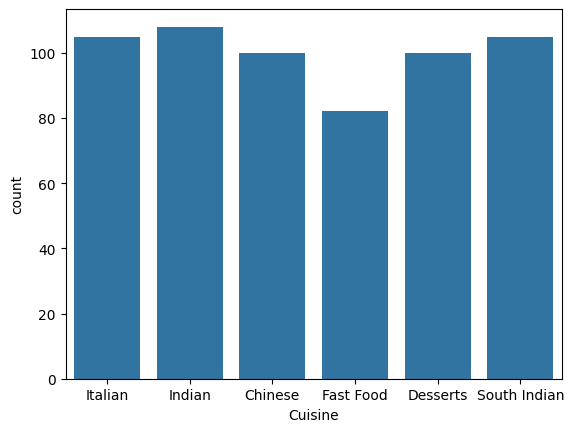

In [38]:
sns.countplot(x=a["Cuisine"])

## Step 6 — Top Restaurants by Revenue

In [ ]:

# TODO:
# Find the top 10 restaurants based on total order value


In [27]:
a.groupby("Restaurant")["Order_Value"].sum().sort_values(ascending=False).head(10)

,Order_Value
Restaurant,
Cafe Delight,28488
Tandoori Treats,26551
Urban Tadka,25475
Royal Bites,24679
Spice Kitchen,23116
Street Eats,23107
Burger Point,21268
Taste of India,20341
Pizza Hub,19788


## Step 7 — Delivery Time Analysis

In [ ]:

# TODO:
# Find average delivery time for each city


In [30]:
a.groupby("City")["Delivery_Time"].mean()

,Delivery_Time
City,
Bangalore,37.181818
Chennai,35.247788
Hyderabad,36.354839
Mumbai,36.744681
Mysore,38.989474
Pune,37.642105


## Step 8 — Discount Impact

In [ ]:

# TODO:
# Check the average order value for each discount level


In [31]:
a.groupby("Discount")["Order_Value"].mean()

,Order_Value
Discount,
0,480.376000
5,538.195876
10,554.931818
15,550.709677
20,590.180328


## Step 9 — Delivery Time vs Customer Rating

In [ ]:

# TODO:
# Create a scatter plot to see relationship between delivery time and rating


<Axes: xlabel='Delivery_Time', ylabel='Customer_Rating'>

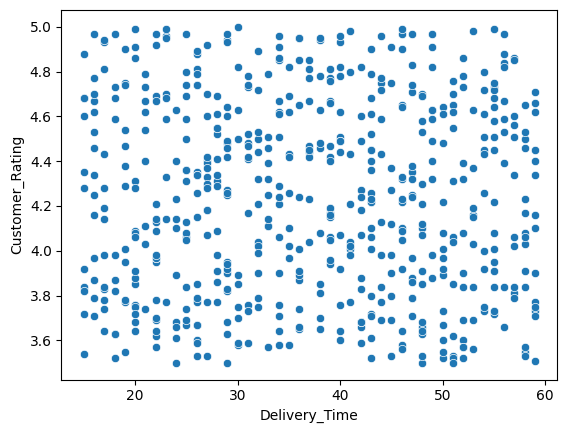

In [33]:
sns.scatterplot(x=a["Delivery_Time"],y=a["Customer_Rating"])

<Axes: xlabel='Delivery_Time', ylabel='Customer_Rating'>

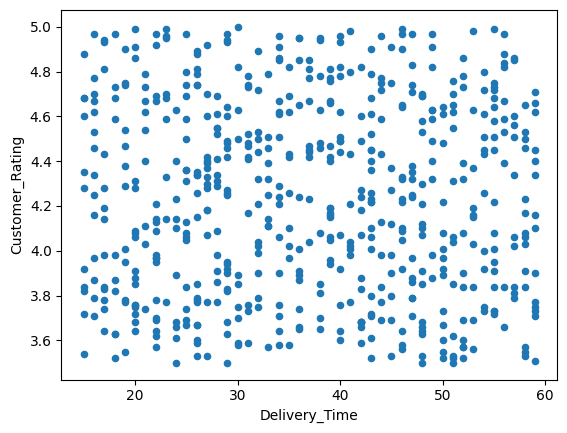

In [34]:
a.plot.scatter(x="Delivery_Time",y="Customer_Rating")


## Step 10 — Prepare Data for Machine Learning

Goal: Predict **Order_Value**

Features to use:
- Delivery_Time
- Customer_Rating
- Discount


In [ ]:

# TODO:
# Define X (features) and y (target)


In [35]:
x=a[["Delivery_Time","Customer_Rating","Discount"]]
y=a["Order_Value"]

In [49]:
a.head()

,Order_ID,City,Restaurant,Cuisine,Delivery_Time,Customer_Rating,Discount,Order_Value
0,1001,Chennai,Spice Kitchen,Italian,48,4.10,10,654
1,1002,Mumbai,Biryani Palace,Indian,25,4.97,0,471
2,1003,Hyderabad,Street Eats,Chinese,55,4.73,15,621
3,1004,Mumbai,Dosa Corner,Fast Food,17,4.28,0,395
4,1005,Mumbai,Taste of India,Italian,42,3.68,15,534


## Step 11 — Train Test Split

In [ ]:

# TODO:
# Split the dataset into training and testing sets
# Hint: train_test_split()


In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Step 12 — Train Machine Learning Model

In [ ]:

# TODO:
# Import LinearRegression
# Train the model using training data


In [58]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

## Step 13 — Make Predictions

In [ ]:

# TODO:
# Predict order values using the test dataset


In [59]:
pred=model.predict(x_test)
pred

array([522.97086639, 544.0262112 , 482.30483921, 590.44871931,
       523.82872607, 527.5224241 , 568.90814626, 504.63418959,
       536.86658104, 529.14806675, 518.55359877, 569.20747127,
       573.98504755, 539.94908286, 577.4642248 , 590.28298545,
       601.11192017, 490.37499059, 500.95338722, 560.00487812,
       555.06156799, 521.53077751, 574.18737159, 494.71577608,
       555.13452496, 528.94539325, 546.4249093 , 489.17769055,
       577.55665222, 513.5014404 , 587.70248215, 516.02963163,
       558.83174814, 530.7381676 , 567.58980126, 550.97541861,
       577.90863877, 530.03419451, 590.01227798, 501.414222  ,
       547.70348841, 510.66560206, 534.12386905, 562.38305738,
       574.39322079, 520.98478903, 556.68381154, 592.80730205,
       512.79359269, 593.87101094, 589.1460962 , 505.16410672,
       489.06849286, 516.36942144, 516.21975894, 514.97014683,
       524.73467375, 587.10735729, 548.08374304, 471.0307916 ,
       592.83979422, 555.38916108, 555.20290839, 534.79

## Step 14 — Evaluate Model Performance

In [61]:

# TODO:
# Calculate Mean Absolute Error
# Calculate R2 Score


In [56]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print("R2_score",r2_score(y_test,pred))
print("MAE",mean_absolute_error(y_test,pred))

R2_score 0.10427476680461223
MAE 109.49404727000292



## Step 15 — Predict New Order Value

Example:
Delivery Time = 25 minutes  
Customer Rating = 4.6  
Discount = 10%


In [ ]:

# TODO:
# Use the trained model to predict order value for a new example


In [65]:
new_data=pd.DataFrame({'Delivery_Time':[25],'Customer_Rating':[4.6],'Discount':[0.1]})
print(model.predict(new_data))

[522.21572696]



## Final Task — Business Recommendations

Write 3 recommendations for Swiggy based on your analysis.

Examples:
- Improve delivery time in certain cities
- Promote popular cuisines
- Offer targeted discounts
